# Task 2 – Simulating the income distribution

The model itself is in `task2_model.py`. This notebook only runs the model, checks it and presents the results.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from task2_model import IncomeModel, gini

## 2.1 The model

The model follows 50,000 people from age 18 to 65. Each person draws an education, enters the labor market as unemployed after education, and then moves between employment and unemployment. Human capital changes over time and income depends on whether the person is studying, employed or unemployed.

The full model is coded in `task2_model.py`, as required in the assignment.

In [2]:
model = IncomeModel(seed=123)
model.simulate()

## 2.2 Simulate the income distribution

### 2.2.1 Check the simulation

First I check the education shares, the unemployment rate and the mean of the human-capital shock. These should be close to the values given in the assignment.

In [3]:
# a. education shares
education_shares = np.array([
    np.mean(model.education == e)
    for e in range(3)
])

print("Simulated education shares:", education_shares)
print("Expected education shares: ", model.p_e)

# b. unemployment
u_ss = model.sigma / (model.sigma + model.lambda_)

for age in [35, 45, 55, 65]:
    t = np.where(model.ages == age)[0][0]
    active = age >= model.age_min + model.education_years
    u_rate = np.mean(~model.employed[active, t])
    print(f"Unemployment age {age}: {u_rate:.4f}")

print(f"Steady-state unemployment: {u_ss:.4f}")

# c. check the hint about psi
rng = np.random.default_rng(123)
psi = rng.lognormal(
    -0.5 * model.sigma_psi**2,
    model.sigma_psi,
    size=model.N
)

print(f"Mean of psi: {psi.mean():.4f}")

Simulated education shares: [0.40006 0.35142 0.24852]
Expected education shares:  [0.4  0.35 0.25]
Unemployment age 35: 0.0787
Unemployment age 45: 0.0755
Unemployment age 55: 0.0758
Unemployment age 65: 0.0773
Steady-state unemployment: 0.0769
Mean of psi: 1.0003


The education shares are basically the 40%, 35% and 25% we put into the model. The unemployment rate is also very close to the steady-state value of about 7.7% at the later ages. The mean of `psi` is almost exactly 1. So the main checks look right.

### 2.2.2 Mean and selected percentiles

I use the 10th percentile, the median and the 90th percentile together with mean income.

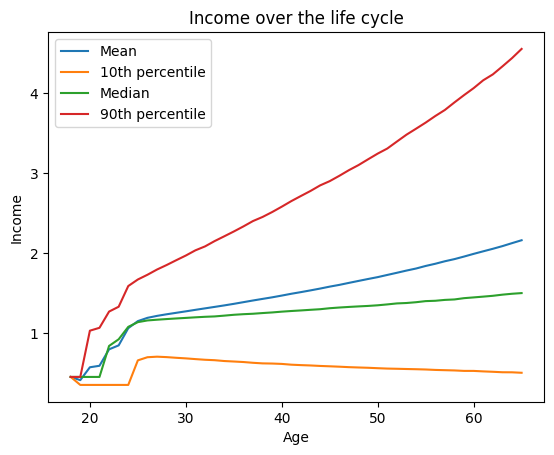

In [4]:
mean_income = np.mean(model.income, axis=0)
p10 = np.percentile(model.income, 10, axis=0)
p50 = np.percentile(model.income, 50, axis=0)
p90 = np.percentile(model.income, 90, axis=0)

plt.figure()

plt.plot(model.ages, mean_income, label="Mean")
plt.plot(model.ages, p10, label="10th percentile")
plt.plot(model.ages, p50, label="Median")
plt.plot(model.ages, p90, label="90th percentile")

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Income over the life cycle")
plt.legend()
plt.show()

Income increases over the life cycle, but the top of the distribution increases much faster. The gap between the 10th and 90th percentile therefore gets bigger with age.

### 2.2.3 Income distributions

The assignment asks for the income distribution at ages 25, 35, 45 and 60.

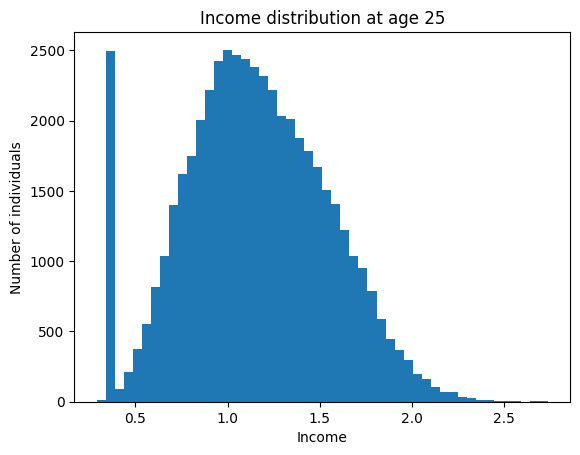

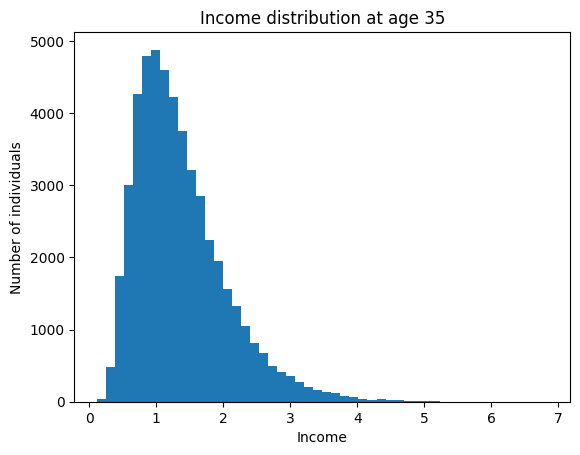

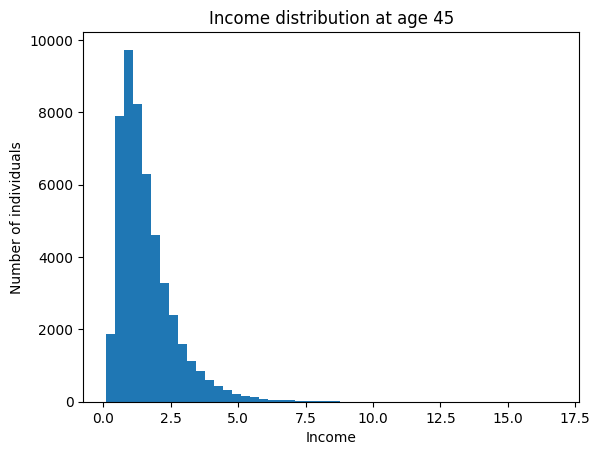

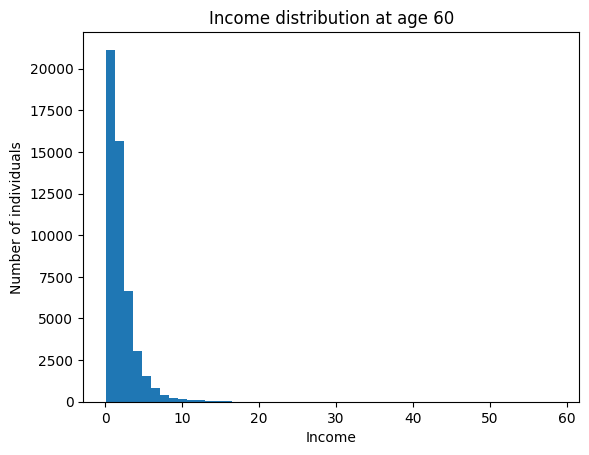

In [5]:
for age in [25, 35, 45, 60]:

    t = np.where(model.ages == age)[0][0]

    plt.figure()
    plt.hist(model.income[:, t], bins=50)

    plt.xlabel("Income")
    plt.ylabel("Number of individuals")
    plt.title(f"Income distribution at age {age}")
    plt.show()

The distribution gets more spread out as people get older. It also becomes more right-skewed, with a longer upper tail. This makes sense because differences in education, employment histories and human-capital shocks build up over time.

## 2.3 Compute the Gini coefficient

The Gini function is written in `task2_model.py`. I first test it on a uniform distribution on [0,1], where the answer should be 1/3.

In [6]:
rng = np.random.default_rng(123)
x_test = rng.uniform(0, 1, size=100_000)

print(f"Simulated Gini: {gini(x_test):.4f}")
print(f"Expected Gini:  {1 / 3:.4f}")

Simulated Gini: 0.3328
Expected Gini:  0.3333


The result is very close to 1/3, so the Gini function passes this simple check.

### 2.3.1 Full sample and Lorenz curve

I pool all people and all ages into one income vector and compute the Gini coefficient.

Gini, all ages pooled: 0.3758


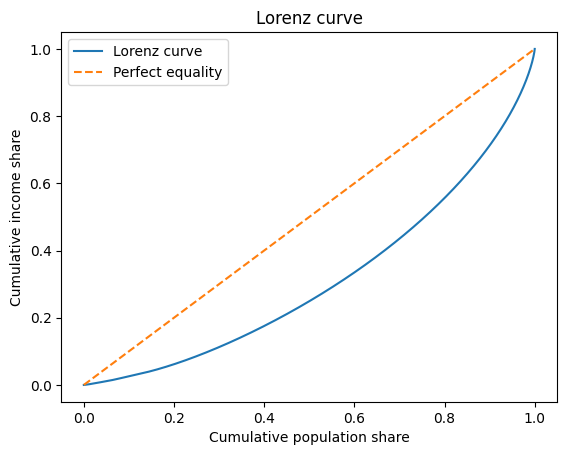

In [7]:
income_all = model.income.flatten()
gini_all = gini(income_all)

print(f"Gini, all ages pooled: {gini_all:.4f}")

income_sorted = np.sort(income_all)

income_share = (
    np.cumsum(income_sorted)
    / np.sum(income_sorted)
)

population_share = (
    np.arange(1, len(income_sorted) + 1)
    / len(income_sorted)
)

plt.figure()

plt.plot(
    population_share,
    income_share,
    label="Lorenz curve"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect equality"
)

plt.xlabel("Cumulative population share")
plt.ylabel("Cumulative income share")
plt.title("Lorenz curve")
plt.legend()
plt.show()

The pooled Gini is around 0.376. The Lorenz curve is clearly below the equality line, so there is a fair amount of income inequality in the simulated sample.

### 2.3.2 Gini by age

Now I compute the Gini separately at every age and compare it with the pooled Gini.

In [8]:
gini_age = np.array([
    gini(model.income[:, t])
    for t in range(len(model.ages))
])

for age in [18, 25, 35, 45, 60, 65]:
    t = np.where(model.ages == age)[0][0]
    print(f"Age {age}: {gini_age[t]:.4f}")

print(f"Average within-age Gini: {gini_age.mean():.4f}")
print(f"Pooled Gini:             {gini_all:.4f}")

Age 18: -0.0000
Age 25: 0.1944
Age 35: 0.2674
Age 45: 0.3374
Age 60: 0.4254
Age 65: 0.4521
Average within-age Gini: 0.3086
Pooled Gini:             0.3758


Inequality within an age group is lower than the pooled inequality on average. The pooled Gini also includes the difference between young and old people. Within-age inequality still rises a lot later in life because shocks and different employment histories have had more time to build up.

## 2.4 What drives inequality?

I switch off one part of the model at a time. I report the Gini for all ages pooled and for age 45, as suggested in the hint.

In [9]:
# a. baseline
baseline = IncomeModel(seed=123)
baseline.simulate()

# b. no educational differences
no_education = IncomeModel(
    seed=123,
    S_e=np.array([3, 3, 3]),
    h_e0=np.array([1.20, 1.20, 1.20]),
    delta_e=np.array([0.020, 0.020, 0.020])
)
no_education.simulate()

# c. no shocks to human capital
no_shocks = IncomeModel(seed=123, sigma_psi=0.0)
no_shocks.simulate()

# d. no depreciation while unemployed
no_depreciation = IncomeModel(seed=123, delta=0.0)
no_depreciation.simulate()

# e. no unemployment
no_unemployment = IncomeModel(seed=123)
no_unemployment.simulate(no_unemployment=True)

models = [
    baseline,
    no_education,
    no_shocks,
    no_depreciation,
    no_unemployment
]

names = [
    "Baseline",
    "No education differences",
    "No human-capital shocks",
    "No depreciation",
    "No unemployment"
]

t45 = np.where(baseline.ages == 45)[0][0]

for name, m in zip(names, models):

    G_all = gini(m.income)
    G_45 = gini(m.income[:, t45])

    print(
        f"{name:25s} "
        f"all ages = {G_all:.4f}, "
        f"age 45 = {G_45:.4f}"
    )

Baseline                  all ages = 0.3758, age 45 = 0.3374
No education differences  all ages = 0.3319, age 45 = 0.2896
No human-capital shocks   all ages = 0.2789, age 45 = 0.2144


No depreciation           all ages = 0.3812, age 45 = 0.3262
No unemployment           all ages = 0.3717, age 45 = 0.3251


The human-capital shocks matter the most in this simulation. When I remove them, the Gini falls the most, both for all ages and at age 45. Educational differences also matter quite a lot.

Removing depreciation or unemployment has a smaller effect. The pooled and age-45 Ginis do not always move exactly the same way. That is because the pooled Gini also includes differences between ages, while the age-45 Gini only compares people at the same age.

## 2.5 Extension: more risk

I add a permanent health shock. Each year there is a 2% risk of being hit. If it happens, human capital falls by 30%, and the job-separation probability increases from 5% to 15% from then on.

I chose this because it is a bigger change than just lowering income for one year. A bad health shock can affect both current and future income.

Baseline Gini, all ages:    0.3758
Health-risk Gini, all ages: 0.3814

Baseline Gini, age 45:      0.3374
Health-risk Gini, age 45:   0.3672

Share hit by health shock by age 65: 0.598


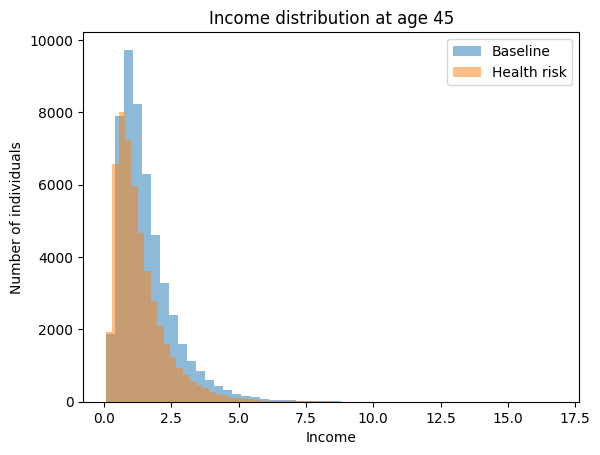

In [10]:
health_model = IncomeModel(seed=123)
health_model.simulate(health_risk=True)

G_base = gini(baseline.income)
G_health = gini(health_model.income)

G_base_45 = gini(baseline.income[:, t45])
G_health_45 = gini(health_model.income[:, t45])

print(f"Baseline Gini, all ages:    {G_base:.4f}")
print(f"Health-risk Gini, all ages: {G_health:.4f}")
print()
print(f"Baseline Gini, age 45:      {G_base_45:.4f}")
print(f"Health-risk Gini, age 45:   {G_health_45:.4f}")
print()
print(
    "Share hit by health shock by age 65: "
    f"{health_model.sick.mean():.3f}"
)

plt.figure()

plt.hist(
    baseline.income[:, t45],
    bins=50,
    alpha=0.5,
    label="Baseline"
)

plt.hist(
    health_model.income[:, t45],
    bins=50,
    alpha=0.5,
    label="Health risk"
)

plt.xlabel("Income")
plt.ylabel("Number of individuals")
plt.title("Income distribution at age 45")
plt.legend()
plt.show()

The health risk increases inequality. The pooled Gini rises from about 0.376 to 0.381, and at age 45 it rises from about 0.337 to 0.367. The histogram also gets more spread out towards lower incomes.

The reason is that some people are hit by a permanent loss of human capital and a higher risk of losing their job, while people who are not hit continue as before.